In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed_data.csv')
print("Loaded:", df.shape)

Loaded: (850, 73)


In [2]:
pip install xgboost



  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [4]:
# Select only pre-breach features for prediction
features = [
    'company_revenue_usd',
    'employee_count',
    'industry_name',
    'attack_vector_primary',
    'data_compromised_records',
    'downtime_hours',
    'is_public_company'
]

target = 'total_loss_usd'

# Keep only rows where target exists
model_df = df[features + [target]].dropna(subset=[target])

# Fill missing feature values with median/mode
model_df['company_revenue_usd'] = model_df['company_revenue_usd'].fillna(model_df['company_revenue_usd'].median())
model_df['employee_count'] = model_df['employee_count'].fillna(model_df['employee_count'].median())
model_df['data_compromised_records'] = model_df['data_compromised_records'].fillna(model_df['data_compromised_records'].median())
model_df['downtime_hours'] = model_df['downtime_hours'].fillna(model_df['downtime_hours'].median())

# Encode categoricals
le_industry = LabelEncoder()
le_attack = LabelEncoder()
model_df['industry_encoded'] = le_industry.fit_transform(model_df['industry_name'].astype(str))
model_df['attack_encoded'] = le_attack.fit_transform(model_df['attack_vector_primary'].astype(str))
model_df['is_public_encoded'] = model_df['is_public_company'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

# Final feature matrix
X = model_df[[
    'company_revenue_usd', 'employee_count', 'industry_encoded',
    'attack_encoded', 'data_compromised_records', 'downtime_hours', 'is_public_encoded'
]]

# Log transform target
y = np.log1p(model_df[target])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", list(X.columns))

X shape: (778, 7)
y shape: (778,)

Features: ['company_revenue_usd', 'employee_count', 'industry_encoded', 'attack_encoded', 'data_compromised_records', 'downtime_hours', 'is_public_encoded']


In [5]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Train all three models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'model': model, 'rmse': rmse, 'r2': r2}
    print(f"\n{name}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

Train: (622, 7), Test: (156, 7)

Linear Regression
  RMSE: 1.6082
  R²:   0.0142

Random Forest
  RMSE: 1.6671
  R²:   -0.0593

XGBoost
  RMSE: 1.8769
  R²:   -0.3427


In [6]:
# Log transform skewed numeric features
X_scaled = X.copy()
X_scaled['company_revenue_usd'] = np.log1p(X['company_revenue_usd'])
X_scaled['employee_count'] = np.log1p(X['employee_count'])
X_scaled['data_compromised_records'] = np.log1p(X['data_compromised_records'])
X_scaled['downtime_hours'] = np.log1p(X['downtime_hours'])

# Retrain with scaled features
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

results2 = {}

for name, model in models.items():
    model.fit(X_train2, y_train2)
    y_pred = model.predict(X_test2)
    
    rmse = np.sqrt(mean_squared_error(y_test2, y_pred))
    r2 = r2_score(y_test2, y_pred)
    
    results2[name] = {'model': model, 'rmse': rmse, 'r2': r2}
    print(f"\n{name}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")


Linear Regression
  RMSE: 1.5865
  R²:   0.0406

Random Forest
  RMSE: 1.6619
  R²:   -0.0527

XGBoost
  RMSE: 1.8769
  R²:   -0.3427


Model saved to data/model.pkl
Encoders saved to data/encoders.pkl


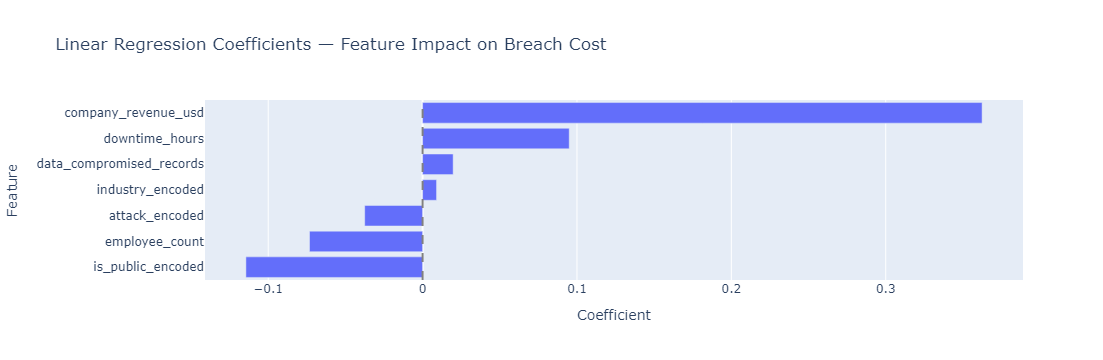

In [7]:
# Linear Regression is best performer - save it
best_model = models['Linear Regression']

# Save model and encoders
with open('../data/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../data/encoders.pkl', 'wb') as f:
    pickle.dump({'industry': le_industry, 'attack': le_attack}, f)

print("Model saved to data/model.pkl")
print("Encoders saved to data/encoders.pkl")

# Feature importance proxy for linear regression - coefficients
import plotly.express as px

coef_df = pd.DataFrame({
    'feature': X_scaled.columns,
    'coefficient': best_model.coef_
}).sort_values('coefficient', ascending=True)

fig = px.bar(coef_df, x='coefficient', y='feature', orientation='h',
             title='Linear Regression Coefficients — Feature Impact on Breach Cost',
             labels={'coefficient': 'Coefficient', 'feature': 'Feature'})
fig.add_vline(x=0, line_dash='dash', line_color='gray')
fig.show()